# Trabajo Práctico N°10 del TPS: Gaussian Variational Bayes


En este trabajo práctico se aborda el problema de modelar los tiempos de llegada de estudiantes a clase mediante modelos probabilísticos. Dado que los datos representan una variable continua (minutos respecto al horario), se asume que los distintos comportamientos de los estudiantes pueden describirse como una mezcla de distribuciones gaussianas, donde cada componente corresponde a un tipo de comportamiento (puntuales, levemente retrasados, muy impuntuales, etc.). Al no contar con etiquetas explícitas, se trata de un problema de aprendizaje no supervisado, en el que se busca descubrir estas estructuras latentes a partir de los datos.

Para ello, se comparan tres enfoques distintos: K-means, como método de clustering basado en distancias; el algoritmo EM, que permite ajustar una mezcla de gaussianas desde una perspectiva probabilística; y finalmente Gaussian Variational Bayes, que introduce un enfoque bayesiano completo, modelando la incertidumbre sobre los parámetros mediante distribuciones a posteriori. Esta comparación permitirá analizar las diferencias entre métodos deterministas, probabilísticos y bayesianos en términos de modelado y capacidad predictiva.

Se empieza por importar las librerías que se utilizarán a lo largo de este trabajo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, digamma, softmax


## (a) Creación del Dataset

En esta primera parte se construye un conjunto sintético de 100 muestras que representa tiempos de llegada (en minutos respecto al inicio de clase). La variable observada es continua y se modela con una mezcla de gaussianas.

Para generar los datos, se parte de una distribución verdadera conocida:

| Parámetro | Valores |
|-----------|---------|
| **Pesos** $\pi$ | 0.1, 0.4, 0.2, 0.3 |
| **Medias** $\mu$ | -4, 0, 4, 5 |
| **Varianzas** $\sigma^2$ | 1, 1.96, 1.44, 1 |

Esto define explícitamente 4 comportamientos de puntualidad:

- **10% - Muy puntuales**: llegan en promedio 4 minutos antes ($\mu=-4$, $\sigma^2=1$).
- **40% - A horario**: llegan alrededor del inicio de clase ($\mu=0$, $\sigma^2=1.96$).
- **20% - Relajados**: suelen llegar algunos minutos tarde ($\mu=4$, $\sigma^2=1.44$).
- **30% - Consistentemente impuntuales**: llegan todavía más tarde, con menor dispersión ($\mu=5$, $\sigma^2=1$).

Es importante remarcar que esta distribución se conoce solo porque fue usada para simular el dataset y servirá como referencia de comparación. En las etapas siguientes, los modelos se entrenan de forma no supervisada sobre las muestras observadas y deben reconstruir esa estructura latente (pesos, medias y varianzas) sin recibir las etiquetas verdaderas de cada componente.

Dataset generado: 100 muestras
Componentes: 4
Pesos: [0.1 0.4 0.2 0.3]
Medias: [-4  0  4  5]
Varianzas: [1.   1.96 1.44 1.  ]

Estadísticas muestrales:
  Media: 1.5924
  Desv. Est.: 3.2217
  Min: -6.0660, Max: 6.5194


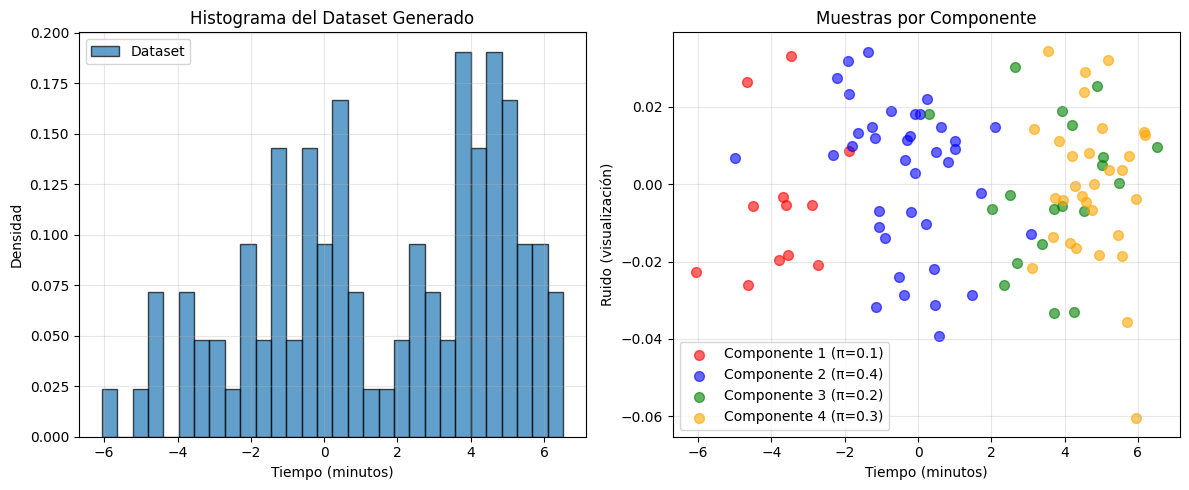

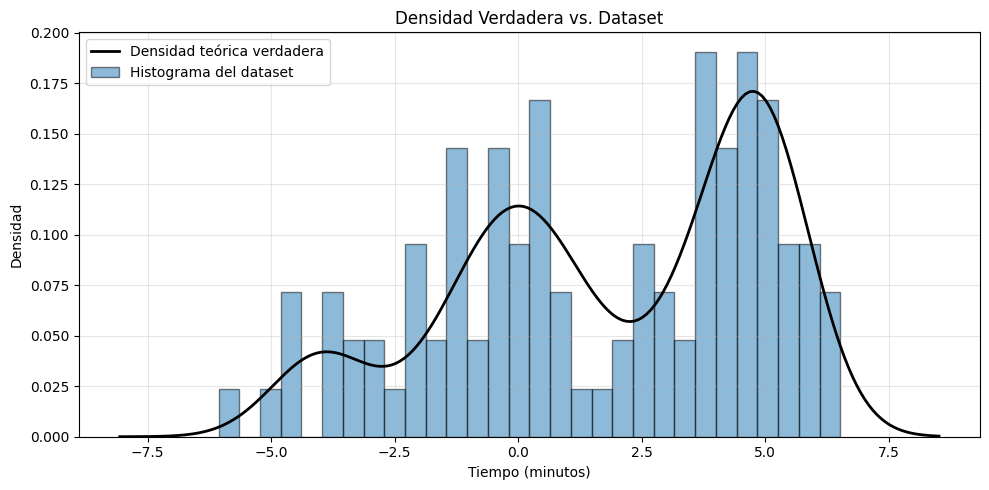

In [2]:
# Configurar semilla para reproducibilidad
np.random.seed(19)

# Parámetros de la mezcla de gaussianas
n_samples = 100
weights = np.array([0.1, 0.4, 0.2, 0.3])
means = np.array([-4, 0, 4, 5])
variances = np.array([1, 1.96, 1.44, 1])
stds = np.sqrt(variances)

# Generar muestras
n_components = len(weights)
component_assignments = np.random.choice(n_components, size=n_samples, p=weights)
X = np.array([np.random.normal(means[comp], stds[comp]) for comp in component_assignments])

print(f"Dataset generado: {n_samples} muestras")
print(f"Componentes: {n_components}")
print(f"Pesos: {weights}")
print(f"Medias: {means}")
print(f"Varianzas: {variances}")
print(f"\nEstadísticas muestrales:")
print(f"  Media: {X.mean():.4f}")
print(f"  Desv. Est.: {X.std():.4f}")
print(f"  Min: {X.min():.4f}, Max: {X.max():.4f}")

# Graficar histograma del dataset
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(X, bins=30, density=True, alpha=0.7, edgecolor='black', label='Dataset')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Densidad')
plt.title('Histograma del Dataset Generado')
plt.legend()
plt.grid(alpha=0.3)

# Graficar scatter plot
plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'orange']
for k in range(n_components):
    mask = component_assignments == k
    plt.scatter(X[mask], np.random.normal(0, 0.02, np.sum(mask)),
               alpha=0.6, s=50, c=colors[k], label=f'Componente {k+1} (π={weights[k]})')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Ruido (visualización)')
plt.title('Muestras por Componente')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Graficar la densidad verdadera teórica
x_range = np.linspace(X.min() - 2, X.max() + 2, 200)
true_density = np.zeros_like(x_range)
for k in range(n_components):
    true_density += weights[k] * (1 / (stds[k] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - means[k]) / stds[k]) ** 2)

plt.figure(figsize=(10, 5))
plt.plot(x_range, true_density, 'k-', linewidth=2, label='Densidad teórica verdadera')
plt.hist(X, bins=30, density=True, alpha=0.5, edgecolor='black', label='Histograma del dataset')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Densidad')
plt.title('Densidad Verdadera vs. Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Los gráficos y estadísticas de la celda anterior muestran resultados consistentes con lo esperado: el histograma presenta la estructura bimodal característica de la mezcla (picos en torno a $\mu=0$, $\mu\approx4$-$5$ y $\mu=-4$), la curva teórica sigue razonablemente al histograma, y la media muestral (\~1.6) y desviación estándar (\~3.2) son acordes a los valores teóricos de la distribución combinada (~1.9 y ~3.2, respectivamente).


### Verificación del *dataset* generado

A continuación se realiza un chequeo más riguroso comparando proporciones y estadísticas por componente contra los valores teóricos.

In [3]:
# VERIFICACIÓN DEL DATASET GENERADO
print("PROPORCIONES POR COMPONENTE")
print("-" * 50)
print(f"{'Componente':<12} {'Esperado':>10} {'Real':>10} {'Real (%)':>10}")
print("-" * 50)
for k in range(n_components):
    n_real = np.sum(component_assignments == k)
    print(f"  k={k+1}       {weights[k]*100:>9.1f}% {n_real:>9d}  ({n_real}%)")
print()

print("ESTADÍSTICAS POR COMPONENTE")
print("-" * 65)
print(f"{'Comp.':<8} {'μ teórica':>10} {'μ muestral':>12} {'σ² teórica':>12} {'σ² muestral':>13}")
print("-" * 65)
for k in range(n_components):
    mask = component_assignments == k
    X_k = X[mask]
    mu_sample = X_k.mean() if len(X_k) > 0 else float('nan')
    var_sample = X_k.var() if len(X_k) > 1 else float('nan')
    print(f"  k={k+1}    {means[k]:>10.2f} {mu_sample:>12.4f} {variances[k]:>12.2f} {var_sample:>13.4f}")
print()

print("ESTADÍSTICAS GLOBALES DE LA MEZCLA")
print("-" * 45)
mu_teo = np.sum(weights * means)
var_teo = np.sum(weights * (variances + means**2)) - mu_teo**2
print(f"  Media   — teórica: {mu_teo:.4f}  |  muestral: {X.mean():.4f}")
print(f"  Varianza— teórica: {var_teo:.4f}  |  muestral: {X.var():.4f}")
print(f"  Desv.Est— teórica: {np.sqrt(var_teo):.4f}  |  muestral: {X.std():.4f}")


PROPORCIONES POR COMPONENTE
--------------------------------------------------
Componente     Esperado       Real   Real (%)
--------------------------------------------------
  k=1            10.0%        12  (12%)
  k=2            40.0%        38  (38%)
  k=3            20.0%        19  (19%)
  k=4            30.0%        31  (31%)

ESTADÍSTICAS POR COMPONENTE
-----------------------------------------------------------------
Comp.     μ teórica   μ muestral   σ² teórica   σ² muestral
-----------------------------------------------------------------
  k=1         -4.00      -3.7930         1.00        1.0753
  k=2          0.00      -0.3523         1.96        2.0392
  k=3          4.00       3.7432         1.44        1.9676
  k=4          5.00       4.7427         1.00        0.7365

ESTADÍSTICAS GLOBALES DE LA MEZCLA
---------------------------------------------
  Media   — teórica: 1.9000  |  muestral: 1.5924
  Varianza— teórica: 10.1620  |  muestral: 10.3790
  Desv.Est— teórica: 

Los resultados confirman que el *dataset* fue generado correctamente. Las proporciones muestrales por componente difieren en a lo sumo 2 muestras respecto a los valores esperados, lo cual es consistente con la variabilidad estadística de $n=100$ observaciones. Las medias muestrales por componente se aproximan a las teóricas con errores menores a 0.4 minutos, y las varianzas muestrales son razonables dado el tamaño reducido de cada subgrupo. A nivel global, la media y varianza de la mezcla coinciden con los valores teóricos ($\mu \approx 1.9$, $\sigma^2 \approx 10.2$) con diferencias despreciables. El dataset está listo para ser utilizado en las etapas siguientes.

### Almacenamiento de parámetros de referencia

Los parámetros verdaderos de la mezcla (pesos, medias, varianzas y función de densidad) se almacenan en el diccionario `true_params`. Dado que estos valores son conocidos únicamente porque se utilizaron para simular el dataset, sirven exclusivamente como referencia para evaluar qué tan bien los modelos no supervisados (K-means, EM y Variational Bayes) logran recuperar la estructura latente en las etapas siguientes.

In [4]:
# Guardar parámetros verdaderos para referencia en análisis posteriores
true_params = {
    'weights': weights,
    'means': means,
    'variances': variances,
    'stds': stds,
    'n_components': n_components,
    'component_assignments': component_assignments,
    'true_density': lambda x: sum(weights[k] * (1 / (stds[k] * np.sqrt(2 * np.pi))) *
                                   np.exp(-0.5 * ((x - means[k]) / stds[k]) ** 2)
                                   for k in range(n_components))
}

print("Dataset listo para análisis con K-means, EM y Gaussian Variational Bayes")

Dataset listo para análisis con K-means, EM y Gaussian Variational Bayes


## (b) K-means

### 1. Implementación del Algoritmo

El algoritmo K-means fue implementado y analizado en detalle en los TPs 6 y 7, por lo que en esta sección se retoma directamente su uso sin profundizar en su derivación.

A modo de repaso, el algoritmo parte de $K$ centroides inicializados aleatoriamente e itera entre dos pasos:

1. **Asignación**: cada punto se asigna al centroide más cercano (en distancia euclídea).
2. **Actualización**: cada centroide se recalcula como el promedio de los puntos asignados a su cluster.

El proceso se repite hasta que se cumple alguna de las dos condiciones de parada: los centroides convergen (el cambio entre iteraciones es menor a una tolerancia $\varepsilon$) o se alcanza el número máximo de iteraciones. Se utiliza $K=4$, consistente con el número de componentes conocido de la mezcla generadora.

En esta implementación, la elección de $\texttt{tol}=10^{-4}$ y $\texttt{max_iter}=100$ se fijó de forma arbitraria, apoyada en la experiencia previa con este tipo de datos y usada como punto de partida razonable para evaluar la convergencia.

In [5]:
class KMeans:
    """
    Algoritmo K-means para clustering de datos continuos.

    Parámetros:
    -----------
    n_clusters : int
        Número de clusters.
    max_iter : int
        Número máximo de iteraciones.
    tol : float
        Tolerancia para convergencia (cambio máximo en centroides).
    random_state : int, optional
        Semilla para reproducibilidad.
    """

    def __init__(self, n_clusters, max_iter=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.history_centroids = []
        self.n_iter = 0

    def fit(self, X):
        """
        Entrena el modelo K-means.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)
            Datos de entrenamiento.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Inicialización: seleccionar centroides aleatoriamente de los datos
        indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[indices].copy()
        self.history_centroids.append(self.centroids.copy())

        for iteration in range(self.max_iter):
            # E-step: asignar cada punto al centroide más cercano
            distances = np.abs(X[:, np.newaxis] - self.centroids)  # shape: (n_samples, n_clusters)
            self.labels = np.argmin(distances, axis=1)

            # M-step: actualizar centroides
            centroids_new = np.array([X[self.labels == k].mean() if np.sum(self.labels == k) > 0
                                      else self.centroids[k]
                                      for k in range(self.n_clusters)])

            # Verificar convergencia
            change = np.max(np.abs(centroids_new - self.centroids))
            self.centroids = centroids_new
            self.history_centroids.append(self.centroids.copy())
            self.n_iter = iteration + 1

            if change < self.tol:
                break

    def predict(self, X):
        """
        Predice el cluster para cada muestra.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)
            Datos a predecir.

        Retorna:
        --------
        labels : ndarray de shape (n_samples,)
            Asignaciones de cluster.
        """
        distances = np.abs(X[:, np.newaxis] - self.centroids)
        return np.argmin(distances, axis=1)

# Entrenar K-means con 4 clusters
kmeans = KMeans(n_clusters=4, max_iter=100, tol=1e-4, random_state=42)
kmeans.fit(X)

print(f"K-means convergió en {kmeans.n_iter} iteraciones")
print(f"Centroides encontrados: {kmeans.centroids}")


K-means convergió en 13 iteraciones
Centroides encontrados: [ 3.39296893 -0.1613655   5.25132666 -3.37048419]


Los resultados obtenidos indican que la configuración inicial de convergencia fue adecuada: K-means convergió en 13 iteraciones, bastante por debajo del máximo permitido, lo que sugiere que $\texttt{tol}$ y $\texttt{max_iter}$ estuvieron bien elegidos para este caso.

Además, los cuatro centroides hallados ($\approx -3.37$, $-0.16$, $3.39$ y $5.25$) muestran una estructura coherente con la mezcla generadora y permiten plantear una primera hipótesis: el algoritmo identifica grupos asociados a perfiles de llegada temprana, en horario y tardía. Esta interpretación se tomará como punto de partida y se validará con mayor detalle en las comparaciones posteriores.

### 2. Modelado de Gaussianas e Inicialización de EM

A partir de los centroides hallados por K-means, se construye una mezcla de gaussianas estimando sus tres parámetros:

- **Medias** $\mu_k$: directamente los centroides obtenidos
- **Pesos** $\pi_k$: proporción de muestras asignadas a cada cluster
- **Varianzas** $\sigma_k^2$: varianza empírica dentro de cada cluster

Esta estimación sirve de inicialización para el algoritmo EM y proporciona un punto de comparación: permite evaluar si K-means logró identificar correctamente la estructura latente de las 4 categorías de puntualidad a partir de los datos sin etiquetar, comparando los parámetros estimados contra los valores verdaderos.

In [6]:
# Estimar parámetros de la mezcla gaussiana a partir de K-means
kmeans_weights = np.array([np.sum(kmeans.labels == k) / len(X) for k in range(kmeans.n_clusters)])
kmeans_means = kmeans.centroids.copy()
kmeans_variances = np.array([np.var(X[kmeans.labels == k]) if np.sum(kmeans.labels == k) > 0
                              else 1.0 for k in range(kmeans.n_clusters)])
kmeans_stds = np.sqrt(kmeans_variances)

print("Parámetros de la mezcla estimados con K-means:")
print(f"\nPesos: {kmeans_weights}")
print(f"Medias: {kmeans_means}")
print(f"Varianzas: {kmeans_variances}")
print(f"\nComparación con parámetros verdaderos:")
print(f"\nPesos verdaderos: {weights}")
print(f"Medias verdaderas: {means}")
print(f"Varianzas verdaderas: {variances}")

# Guardar parámetros estimados por K-means
kmeans_params = {
    'weights': kmeans_weights,
    'means': kmeans_means,
    'variances': kmeans_variances,
    'stds': kmeans_stds,
    'labels': kmeans.labels
}


Parámetros de la mezcla estimados con K-means:

Pesos: [0.26 0.3  0.26 0.18]
Medias: [ 3.39296893 -0.1613655   5.25132666 -3.37048419]
Varianzas: [0.58871861 0.6303686  0.34065624 1.4910831 ]

Comparación con parámetros verdaderos:

Pesos verdaderos: [0.1 0.4 0.2 0.3]
Medias verdaderas: [-4  0  4  5]
Varianzas verdaderas: [1.   1.96 1.44 1.  ]



A partir de los resultados de la celda anterior se pueden inferir los siguiente puntos:

**Medias (centroides):** K-means logró identificar correctamente las 4 categorías. Los errores son menores a 0.7 minutos respecto a los valores verdaderos. Esta es la fortaleza de K-means: encuentra bien los "centros" de los clusters.

**Pesos (proporciones):** Se observan desviaciones significativas. El cluster mayoritario (40%) fue subestimado a 30%, mientras que el minoritario (10%) fue sobrestimado a 26%. La causa es que K-means usa asignaciones duras: cada punto pertenece exactamente a un cluster. Si un punto está mal asignado (por sobreposición entre distribuciones), distorsiona el conteo final.

**Varianzas:** K-means subestima sistemáticamente las varianzas. El cluster más disperso (σ²=1.96) fue estimado en 0.63 (error de 68%). Esto ocurre porque:
- K-means minimiza la suma de distancias cuadradas dentro de clusters
- Las asignaciones duras hacen que puntos de fronteras se asignen al centroide más cercano, incluso si pertenecen a otro cluster
- Esto "comprime" artificialmente los clusters, reduciendo sus varianzas observadas

**Conclusión:** K-means descubrió las 4 categorías de puntualidad pero con parámetros crudos (medias bien, pero pesos y varianzas incorrectos).

### 3. Visualización

Para dar una mayor validez a la conclusión llegada en la celda anterior, se grafica la densidad de probabilidad estimada por K-means junto con el histograma del dataset y la densidad verdadera para evaluar qué tan bien el algoritmo logró recuperar la estructura latente.

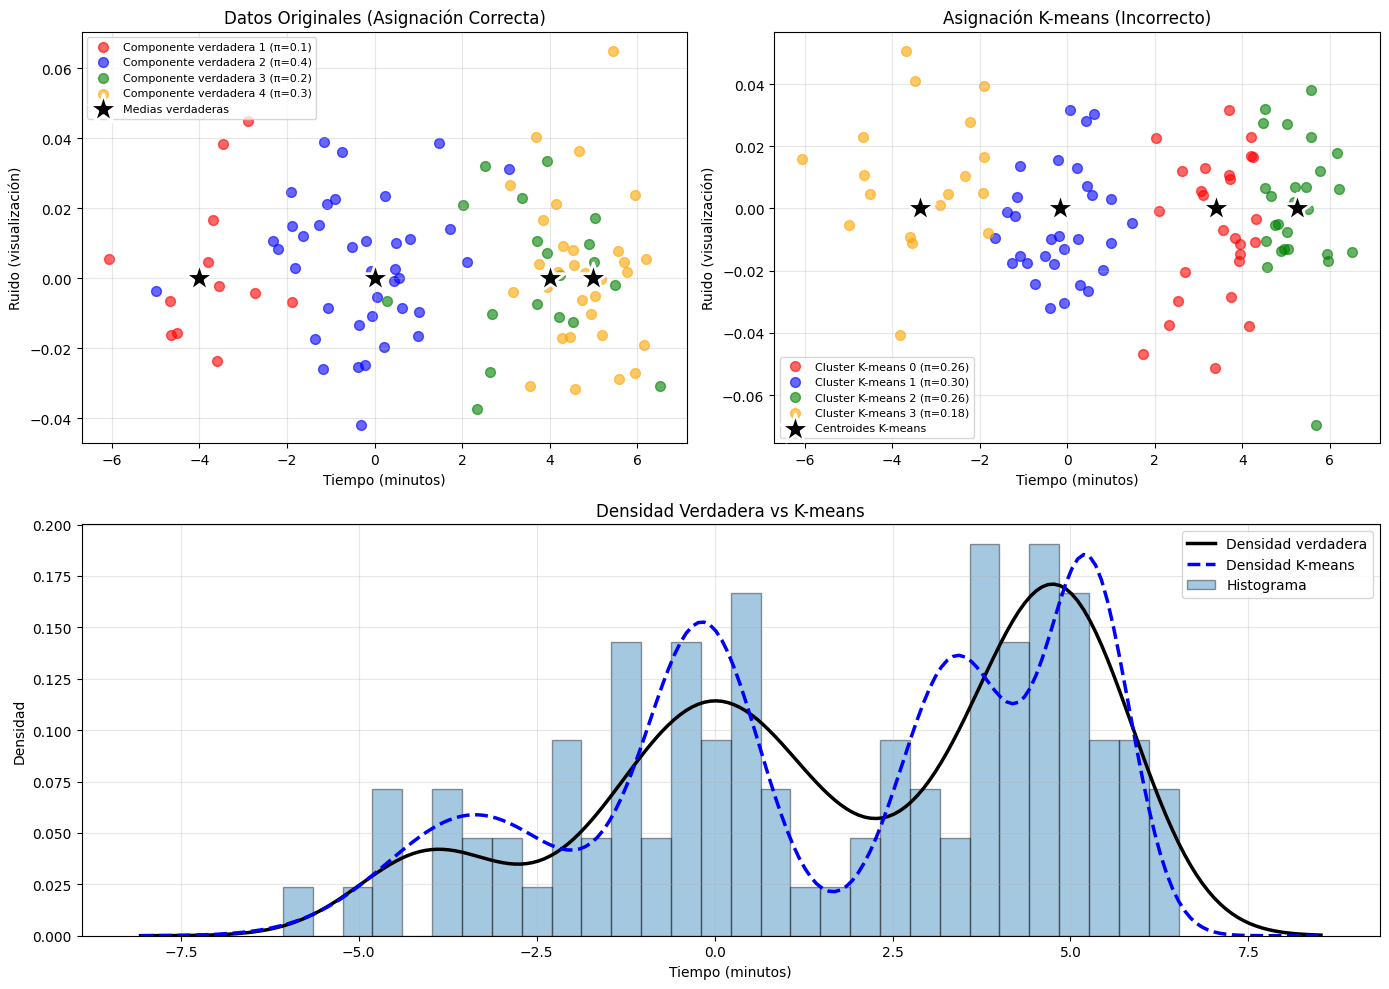

Diferencia promedio entre densidades (MAE): 0.015868


In [8]:
# Calcular densidad estimada por K-means
x_range = np.linspace(X.min() - 2, X.max() + 2, 200)
kmeans_density = np.zeros_like(x_range)
for k in range(kmeans.n_clusters):
    kmeans_density += kmeans_weights[k] * (1 / (kmeans_stds[k] * np.sqrt(2 * np.pi))) * \
                      np.exp(-0.5 * ((x_range - kmeans_means[k]) / kmeans_stds[k]) ** 2)

# Graficar comparación con K-means
fig = plt.figure(figsize=(14, 10))

# Gráfico 1: Datos originales (verdadera asignación)
ax1 = plt.subplot(2, 2, 1)
colors = ['red', 'blue', 'green', 'orange']
for k in range(n_components):
    mask = component_assignments == k
    ax1.scatter(X[mask], np.random.normal(0, 0.02, np.sum(mask)),
               alpha=0.6, s=50, c=colors[k], label=f'Componente verdadera {k+1} (π={weights[k]})')
ax1.scatter(means, np.zeros(n_components), marker='*', s=500,
           c='black', edgecolors='white', linewidths=2, label='Medias verdaderas', zorder=5)
ax1.set_xlabel('Tiempo (minutos)')
ax1.set_ylabel('Ruido (visualización)')
ax1.set_title('Datos Originales (Asignación Correcta)')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Gráfico 2: Asignaciones de clusters por K-means
ax2 = plt.subplot(2, 2, 2)
for k in range(kmeans.n_clusters):
    mask = kmeans.labels == k
    ax2.scatter(X[mask], np.random.normal(0, 0.02, np.sum(mask)),
               alpha=0.6, s=50, c=colors[k], label=f'Cluster K-means {k} (π={kmeans_weights[k]:.2f})')
ax2.scatter(kmeans_means, np.zeros(kmeans.n_clusters), marker='*', s=500,
           c='black', edgecolors='white', linewidths=2, label='Centroides K-means', zorder=5)
ax2.set_xlabel('Tiempo (minutos)')
ax2.set_ylabel('Ruido (visualización)')
ax2.set_title('Asignación K-means (Incorrecto)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Gráfico 3: Densidad estimada vs verdadera (abajo, ancho completo)
ax3 = plt.subplot(2, 1, 2)
ax3.plot(x_range, true_density, 'k-', linewidth=2.5, label='Densidad verdadera')
ax3.plot(x_range, kmeans_density, 'b--', linewidth=2.5, label='Densidad K-means')
ax3.hist(X, bins=30, density=True, alpha=0.4, edgecolor='black', label='Histograma')
ax3.set_xlabel('Tiempo (minutos)')
ax3.set_ylabel('Densidad')
ax3.set_title('Densidad Verdadera vs K-means')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Diferencia promedio entre densidades (MAE): {np.mean(np.abs(true_density - kmeans_density)):.6f}")

Comparando el gráfico de datos originales con el de K-means se ve claramente el problema:

En el gráfico original, cada color representa la verdadera componente generadora. En cambio, en el gráfico de K-means los colores ya no respetan esa estructura: aparecen puntos de un mismo color en regiones donde no deberían estar. Es decir, puntos que pertenecen a una componente terminan asignados a otra.

Esto ocurre porque K-means hace asignaciones duras: a cada punto le asigna un único cluster, el del centroide más cercano, usando solo distancia. No modela incertidumbre ni solapamiento entre distribuciones.

Cuando las gaussianas se superponen (especialmente entre las componentes alrededor de 0 y 4), aparecen puntos en zonas intermedias sin pertenencia clara. K-means, al usar asignaciones duras, los fuerza a elegir el centroide más cercano, generando mezclas de colores incorrectas respecto al gráfico original.

Esas malas asignaciones son exactamente las que explican los parámetros estimados. Al “robarse” puntos entre clusters, los pesos quedan distorsionados (por ejemplo, el 40% baja a 30%), y al formar grupos artificialmente compactos, las varianzas se subestiman fuertemente (por ejemplo, 1.96 → 0.63). El gráfico de densidad confirma esto: aunque la forma general se aproxima (MAE = 0.015868), aparecen picos mal escalados y demasiado angostos. En conjunto, los gráficos confirman visualmente el mismo problema ya observado en los parámetros: K-means clasifica mal los puntos en zonas de solapamiento, y eso deforma toda la estimación.


K-means funciona bien para ubicar los centros y capturar la forma gruesa de la distribución, pero falla en el modelado fino porque:

- fuerza asignaciones duras incluso donde no corresponde  
- no puede manejar correctamente el solapamiento entre componentes  

Por eso, aunque la densidad parece cercana, los parámetros subyacentes (pesos y varianzas) quedan mal estimados. Esto motiva el uso de EM, que reemplaza estas decisiones rígidas por asignaciones probabilísticas.

**Nota:** Se consideró iterar K-means más veces para verificar convergencia. Sin embargo, no se avanzó con más iteraciones porque la distribución observada sugiere desde el inicio una geometría poco adecuada para K-means (solapamiento y estructura no esférica). Por eso, más iteraciones no cambiarían la conclusión principal, sino que solo ajustarían una partición ya sesgada por el modelo.

## (c) Expectation-Maximization

A partir de los resultados obtenidos con K-means surge naturalmente la motivación para aplicar el algoritmo EM. Si bien K-means logró identificar correctamente la ubicación de los centroides y aproximar la forma general de la distribución, falló en el modelado fino debido a sus asignaciones duras, lo que llevó a errores en los pesos y varianzas al haber puntos mal clasificados en las zonas de solapamiento.

En este contexto, se propone utilizar Expectation-Maximization (EM) para modelar la mezcla de gaussianas desde un enfoque probabilístico. A diferencia de K-means, EM utiliza asignaciones suaves, permitiendo que cada punto pertenezca parcialmente a múltiples componentes según su probabilidad.

El algoritmo se inicializa a partir de los parámetros obtenidos con K-means (medias, pesos y varianzas). Esto permite aprovechar la buena estimación inicial de los centroides y refinar el resto de los parámetros mediante un modelo que sí puede captar la incertidumbre en las asignaciones.

De esta forma, EM actúa como una mejora directa sobre K-means: parte de su solución inicial y corrige sus limitaciones, especialmente en presencia de componentes superpuestos.

### 1. Implementación del Algoritmo

In [9]:
class GaussianMixtureEM:
    """
    Algoritmo EM para mezcla de gaussianas univariadas.

    Parámetros:
    -----------
    n_components : int
        Número de componentes de la mezcla.
    max_iter : int
        Número máximo de iteraciones.
    tol : float
        Tolerancia de convergencia (cambio mínimo en log-verosimilitud).
    random_state : int, optional
        Semilla para reproducibilidad (solo usada si no hay inicialización externa).
    """

    def __init__(self, n_components, max_iter=200, tol=1e-6, random_state=None):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.weights = None
        self.means = None
        self.variances = None
        self.log_likelihoods = []
        self.n_iter = 0

    def _gaussian(self, x, mu, sigma2):
        """Evalúa la densidad N(x | mu, sigma2)."""
        return (1.0 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-0.5 * (x - mu) ** 2 / sigma2)

    def _log_likelihood(self, X):
        """Calcula la log-verosimilitud del dataset bajo el modelo actual."""
        N = len(X)
        ll = 0.0
        for n in range(N):
            p = sum(self.weights[k] * self._gaussian(X[n], self.means[k], self.variances[k])
                    for k in range(self.n_components))
            ll += np.log(p + 1e-300)
        return ll

    def fit(self, X, init_weights=None, init_means=None, init_variances=None):
        """
        Entrena el modelo EM.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)
            Datos de entrenamiento.
        init_weights, init_means, init_variances : ndarray, optional
            Inicialización externa (ej. desde K-means). Si no se proveen,
            se inicializa aleatoriamente.
        """
        N = len(X)

        # Inicialización
        if init_weights is not None and init_means is not None and init_variances is not None:
            self.weights = init_weights.copy()
            self.means = init_means.copy()
            self.variances = init_variances.copy()
        else:
            if self.random_state is not None:
                np.random.seed(self.random_state)
            idx = np.random.choice(N, self.n_components, replace=False)
            self.means = X[idx].copy()
            self.variances = np.full(self.n_components, X.var())
            self.weights = np.ones(self.n_components) / self.n_components

        self.log_likelihoods = [self._log_likelihood(X)]

        for iteration in range(self.max_iter):
            # ------------------------------------------------------------------
            # E-step: calcular responsabilidades r[n, k]
            # ------------------------------------------------------------------
            R = np.zeros((N, self.n_components))
            for k in range(self.n_components):
                R[:, k] = self.weights[k] * self._gaussian(X, self.means[k], self.variances[k])
            R_sum = R.sum(axis=1, keepdims=True)
            R /= (R_sum + 1e-300)

            # ------------------------------------------------------------------
            # M-step: actualizar parámetros
            # ------------------------------------------------------------------
            N_k = R.sum(axis=0)  # cantidad efectiva de puntos por componente

            self.weights = N_k / N
            self.means = (R * X[:, np.newaxis]).sum(axis=0) / (N_k + 1e-300)
            self.variances = np.array([
                (R[:, k] * (X - self.means[k]) ** 2).sum() / (N_k[k] + 1e-300)
                for k in range(self.n_components)
            ])
            # Evitar varianzas degeneradas
            self.variances = np.maximum(self.variances, 1e-6)

            # ------------------------------------------------------------------
            # Verificar convergencia
            # ------------------------------------------------------------------
            ll = self._log_likelihood(X)
            self.log_likelihoods.append(ll)
            self.n_iter = iteration + 1

            if abs(ll - self.log_likelihoods[-2]) < self.tol:
                break

    def predict_proba(self, X):
        """
        Retorna las responsabilidades r[n, k] para cada muestra.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)

        Retorna:
        --------
        R : ndarray de shape (n_samples, n_components)
        """
        N = len(X)
        R = np.zeros((N, self.n_components))
        for k in range(self.n_components):
            R[:, k] = self.weights[k] * self._gaussian(X, self.means[k], self.variances[k])
        R_sum = R.sum(axis=1, keepdims=True)
        return R / (R_sum + 1e-300)

    def predict(self, X):
        """
        Asigna cada muestra a la componente con mayor responsabilidad.

        Parámetros:
        -----------
        X : ndarray de shape (n_samples,)

        Retorna:
        --------
        labels : ndarray de shape (n_samples,)
        """
        return np.argmax(self.predict_proba(X), axis=1)


# Entrenar EM inicializado con los parámetros de K-means
em = GaussianMixtureEM(n_components=4, max_iter=200, tol=1e-6)
em.fit(X,
       init_weights=kmeans_params['weights'],
       init_means=kmeans_params['means'],
       init_variances=kmeans_params['variances'])

print(f"EM convergió en {em.n_iter} iteraciones")
print(f"\nParámetros estimados por EM:")
print(f"  Pesos:     {em.weights}")
print(f"  Medias:    {em.means}")
print(f"  Varianzas: {em.variances}")
print(f"\nComparación con parámetros verdaderos:")
print(f"  Pesos:     {weights}")
print(f"  Medias:    {means}")
print(f"  Varianzas: {variances}")

# Guardar parámetros EM
em_params = {
    'weights': em.weights,
    'means': em.means,
    'variances': em.variances,
    'stds': np.sqrt(em.variances),
    'labels': em.predict(X)
}


EM convergió en 200 iteraciones

Parámetros estimados por EM:
  Pesos:     [0.21482156 0.37644863 0.29037761 0.1183522 ]
  Medias:    [ 3.63309132 -0.3983222   4.93001775 -3.96836935]
  Varianzas: [1.09642579 1.42941238 0.66732627 1.10464845]

Comparación con parámetros verdaderos:
  Pesos:     [0.1 0.4 0.2 0.3]
  Medias:    [-4  0  4  5]
  Varianzas: [1.   1.96 1.44 1.  ]


### 2. Visualización

Se grafican las densidades estimadas por EM y K-means junto con la densidad verdadera, y la evolución de la log-verosimilitud a lo largo de las iteraciones del algoritmo.

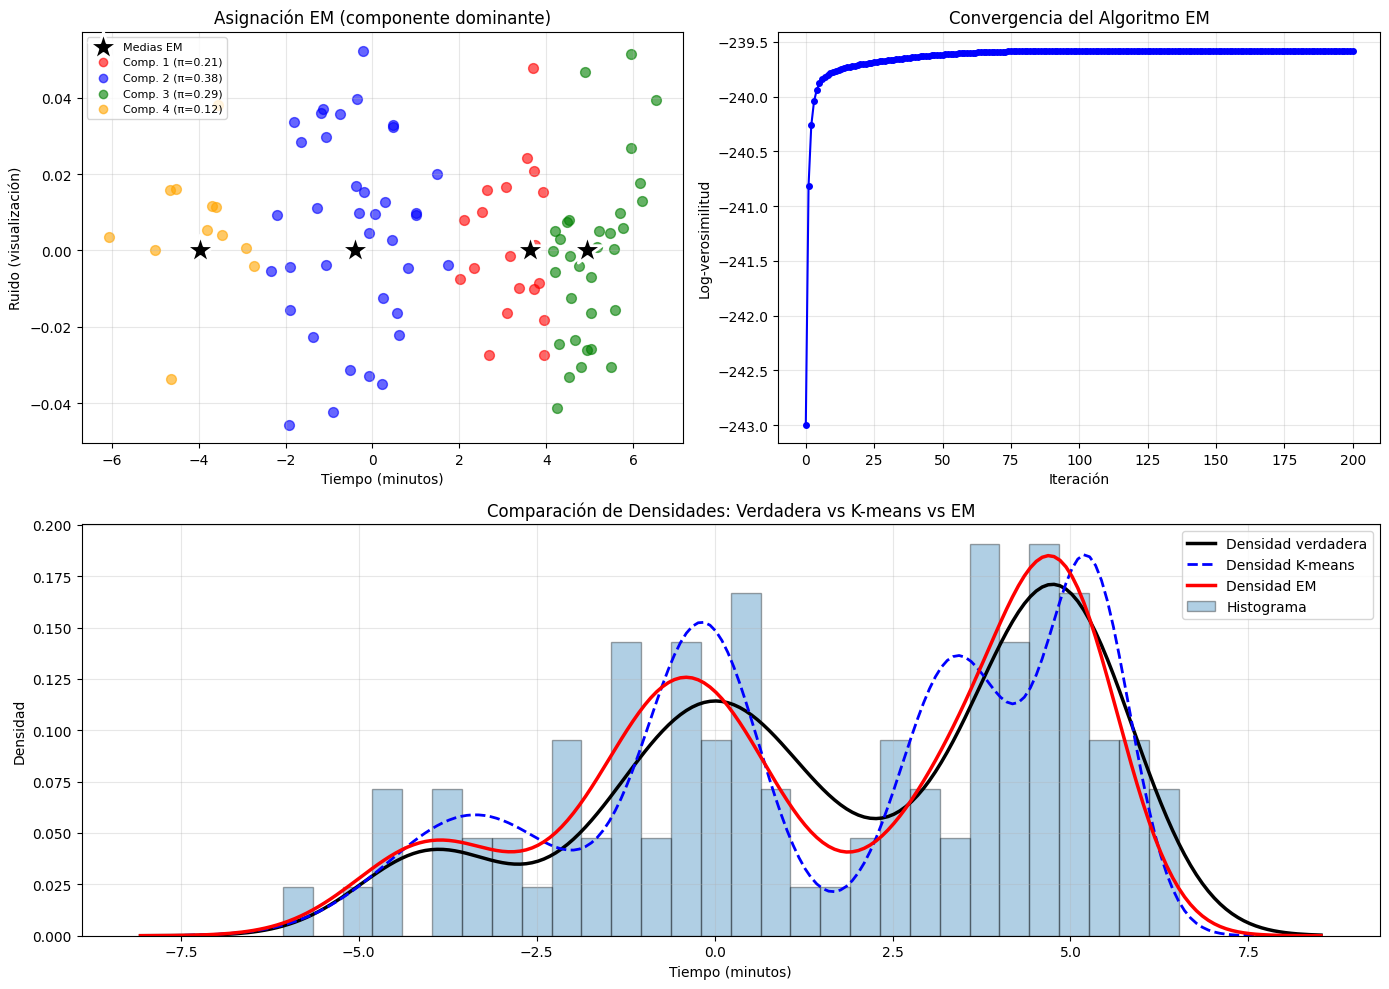

MAE K-means: 0.015868
MAE EM:      0.009412
Reducción de error: 40.7%


In [10]:
# Calcular densidades estimadas
x_range = np.linspace(X.min() - 2, X.max() + 2, 200)

em_density = np.zeros_like(x_range)
for k in range(em.n_components):
    em_density += em.weights[k] * (1 / (em_params['stds'][k] * np.sqrt(2 * np.pi))) * \
                  np.exp(-0.5 * ((x_range - em.means[k]) / em_params['stds'][k]) ** 2)

kmeans_density = np.zeros_like(x_range)
for k in range(kmeans.n_clusters):
    kmeans_density += kmeans_weights[k] * (1 / (kmeans_stds[k] * np.sqrt(2 * np.pi))) * \
                      np.exp(-0.5 * ((x_range - kmeans_means[k]) / kmeans_stds[k]) ** 2)

fig = plt.figure(figsize=(14, 10))

# Gráfico 1: Asignaciones blandas EM (responsabilidades)
ax1 = plt.subplot(2, 2, 1)
R_all = em.predict_proba(X)
colors = ['red', 'blue', 'green', 'orange']
for n in range(len(X)):
    dominant = np.argmax(R_all[n])
    ax1.scatter(X[n], np.random.normal(0, 0.02), alpha=0.6, s=50, c=colors[dominant])
ax1.scatter(em.means, np.zeros(em.n_components), marker='*', s=500,
            c='black', edgecolors='white', linewidths=2, label='Medias EM', zorder=5)
for k in range(em.n_components):
    ax1.scatter([], [], c=colors[k], label=f'Comp. {k+1} (π={em.weights[k]:.2f})', alpha=0.6)
ax1.set_xlabel('Tiempo (minutos)')
ax1.set_ylabel('Ruido (visualización)')
ax1.set_title('Asignación EM (componente dominante)')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Gráfico 2: Convergencia de la log-verosimilitud
ax2 = plt.subplot(2, 2, 2)
ax2.plot(em.log_likelihoods, 'b-o', markersize=4, linewidth=1.5)
ax2.set_xlabel('Iteración')
ax2.set_ylabel('Log-verosimilitud')
ax2.set_title('Convergencia del Algoritmo EM')
ax2.grid(alpha=0.3)

# Gráfico 3: Comparación de densidades (ancho completo)
ax3 = plt.subplot(2, 1, 2)
ax3.plot(x_range, true_density, 'k-', linewidth=2.5, label='Densidad verdadera')
ax3.plot(x_range, kmeans_density, 'b--', linewidth=2, label='Densidad K-means')
ax3.plot(x_range, em_density, 'r-', linewidth=2.5, label='Densidad EM')
ax3.hist(X, bins=30, density=True, alpha=0.35, edgecolor='black', label='Histograma')
ax3.set_xlabel('Tiempo (minutos)')
ax3.set_ylabel('Densidad')
ax3.set_title('Comparación de Densidades: Verdadera vs K-means vs EM')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

mae_kmeans = np.mean(np.abs(true_density - kmeans_density))
mae_em     = np.mean(np.abs(true_density - em_density))
print(f"MAE K-means: {mae_kmeans:.6f}")
print(f"MAE EM:      {mae_em:.6f}")
print(f"Reducción de error: {(1 - mae_em / mae_kmeans) * 100:.1f}%")
